# Strategy Router — query taxonomy demo

Four beats:

1. **Live extraction** — one call, two engines cooperating (regex + spaCy) with claim resolution.
2. **The four signals** — every scalar we emit answers one question the router cares about. Contrast pairs show each signal moving.
3. **Corpus fingerprints** — same extractor, three retrieval corpora, three completely different profiles.
4. **The self-audit** — the profiler discovered a taxonomy gap on SciFact. Building the dataset improves the tool that builds the dataset.

> Run the first import cell BEFORE the meeting — `engines=None` triggers the pinned spaCy model load (~2s cold).

## Beat 1 — live extraction

In [1]:
# Warm the extractor. engines=None = every engine (regex + spaCy).
# First call loads the pinned spaCy pipeline; subsequent calls are cheap
# (shared lru_cache).
from query_taxonomy.features import FeatureExtractor

extractor = FeatureExtractor(engines=None)
print("loaded — banks per group:")
for group, banks in extractor._by_group.items():
    engines = sorted({b.engine.value for b in banks})
    print(f"  {group.value:<24} {len(banks):>2} banks  engines: {engines}")

loaded — banks per group:
  structured_identifiers   79 banks  engines: ['regex']
  sentence_markers          6 banks  engines: ['regex']
  logical_structures        4 banks  engines: ['regex']
  statistical_metrics       6 banks  engines: ['regex', 'spacy_model']


In [2]:
# One handpicked query — both engines have something to say about it.
#
# regex : v2.1.0 (semver), 192.168.0.1 (ipv4), $750 (currency)
# spacy : the four signal scalars (NL-shape, word variation, structure, size)
#
# Claim registry ensures NUMBER can't steal `2.1.0` out of `v2.1.0`.

query = (
    "How do I upgrade to v2.1.0 on 192.168.0.1 before October in Berlin, "
    "per Dr. Smith's $750 quote?"
)

features = extractor.resolve(query)

print(f"query: {query}\n")
print("SPANS (claim-resolved, by group):")
for group, by_type in features.spans.items():
    print(f"  == {group.value}")
    for type_, matches in by_type.items():
        forms = ", ".join(m.text for m in matches)
        print(f"     {type_:<14} -> {forms}")

print("\nSTATS (all of them — the metrics group is this lean):")
for metrics in features.stats.values():
    for metric, stats in metrics.items():
        for stat in stats:
            print(f"     {f'{metric}.{stat.name}':<46} = {stat.value:.3f}")

query: How do I upgrade to v2.1.0 on 192.168.0.1 before October in Berlin, per Dr. Smith's $750 quote?

SPANS (claim-resolved, by group):
  == structured_identifiers
     ip_address     -> 192.168.0.1
     currency_amount -> $750
     version_string -> v2.1.0

STATS (all of them — the metrics group is this lean):
     length.length_words                            = 23.000
     length.length_chars                            = 95.000
     stopword_ratio.stopword_ratio                  = 0.304
     natural_language_signal.natural_language_share = 0.476
     morphology.word_variation_share                = 0.000
     syntactic_depth.nesting_depth                  = 4.000
     syntactic_depth.statement_count                = 1.000
     coordination.widest_list_size                  = 0.000


## Beat 2 — the four signals

The metrics group is deliberately tiny: **four signals, seven scalars**. Every one answers a question the router cares about — correlated with which retrieval strategy (dense / sparse / hybrid) wins. Anything that didn't answer such a question (the UD-17 POS histogram, derived shares, raw counts) was pruned, and the names say what a scalar *means*, not how it's computed — the mechanism lives in the bank docstrings.

| Signal | Scalar(s) | The question | How to read it |
| --- | --- | --- | --- |
| **NL-shape** | `natural_language_signal.natural_language_share` (regex fallback: `stopword_ratio`) | How natural-language-shaped is the query? | ≈0.0 = keyword telegram → sparse is safe; 0.4–0.5 = proper sentence → dense wins |
| **Word variation** | `morphology.word_variation_share` | How many words are not in their dictionary form (running → run)? | high → embeddings abstract over word forms; 0.0 → exact-match BM25 is not tripped up |
| **Structure** | `syntactic_depth.nesting_depth`, `statement_count` | How much compositional meaning would a bag-of-words lose? | deeply nested / multi-statement → dense or decompose+rerank; flat → sparse safe |
| **Size** | `length.length_words`, `length_chars` | How big is the query? | short telegrams ≠ long questions; also the normalizer behind every share |

Two doctrine points:

- **Signals are coordinates and acceptance filters** for dataset work — strata are boxes in this signal space, and synthetic queries are rejection-sampled against them. They are **never label sources**: labels come from retrieval outcomes, otherwise the router just learns our heuristic back.
- **Signals are read jointly**, not in isolation — see the caveat below.

In [3]:
# Minimal contrast pairs — per signal, two queries where (mostly) that one
# signal moves. This is the "why": each scalar tracks something that
# changes which retrieval strategy wins.
#
# NOTE the word-variation pair drops "best" from both sides: spaCy
# lemmatizes best -> good, which would leak variation into the telegram.

PAIRS = [
    ("NL-shape", "natural_language_share",
     "how do i restore a postgres backup from s3",
     "postgres backup restore s3"),
    ("word variation", "word_variation_share",
     "running shoes for flat feet",
     "run shoe flat foot"),
    ("structure", "nesting_depth",
     "the paper that introduced the attention mechanism used in transformers",
     "attention mechanism paper"),
]


def signal(text: str, name: str) -> float:
    f = extractor.resolve(text)
    return next(
        stat.value
        for metrics in f.stats.values()
        for stats in metrics.values()
        for stat in stats
        if stat.name == name
    )


for label, stat_name, natural, telegram in PAIRS:
    print(f"{label} ({stat_name}):")
    print(f"  {signal(natural, stat_name):>6.3f}  {natural!r}")
    print(f"  {signal(telegram, stat_name):>6.3f}  {telegram!r}")
    print()

NL-shape (natural_language_share):
   0.556  'how do i restore a postgres backup from s3'
   0.000  'postgres backup restore s3'

word variation (word_variation_share):
   0.600  'running shoes for flat feet'
   0.000  'run shoe flat foot'

structure (nesting_depth):
   5.000  'the paper that introduced the attention mechanism used in transformers'
   2.000  'attention mechanism paper'



**The joint-reading caveat.** The parser *hallucinates* structure on non-sentences: a bare identifier telegram can out-depth a real question, because the dependency parser must produce a tree even for input that has no grammar. So `nesting_depth` is only meaningful **conditional on** `natural_language_share` saying "this is actually natural language". That is not a bug to fix — it's why the signals are one panel, not four independent columns.

In [4]:
# The caveat, live: a pure identifier telegram vs a real NL question.
# The telegram has NO grammar, yet the parser still assigns it depth —
# read nesting_depth only where natural_language_share says the query is NL.

for q in (
    "CVE-2024-3094 xz-utils sshd 5.6.0 backdoor",
    "why do cats knead blankets when they are happy",
):
    nl_share = signal(q, "natural_language_share")
    depth = signal(q, "nesting_depth")
    verdict = "NL -> depth is meaningful" if nl_share > 0.25 else "telegram -> depth is parser noise"
    print(f"natural_language_share={nl_share:.3f}  nesting_depth={depth:.0f}  ({verdict})")
    print(f"  {q!r}\n")

natural_language_share=0.111  nesting_depth=4  (telegram -> depth is parser noise)
  'CVE-2024-3094 xz-utils sshd 5.6.0 backdoor'

natural_language_share=0.556  nesting_depth=2  (NL -> depth is meaningful)
  'why do cats knead blankets when they are happy'



## Beat 3 — corpus fingerprints

Same extractor, three retrieval corpora (`TrecDL2022(30000)`, `NFCorpus`, `SciFact`), three completely different profiles. These summaries were pre-computed by `src/profile_datasets.py`.

In [5]:
# Beat 3, live: render the CorpusReport text for each cached profile.
# The profiles JSON was written by src/profile_datasets.py; the .summary.txt
# files on disk are the same text CorpusReport(...).text() produces below.

from pathlib import Path

from query_taxonomy.features import CorpusFeatures
from query_taxonomy.reporting import CorpusReport

PROFILES = Path("data/profiles")

reports = {
    name: CorpusReport(
        CorpusFeatures.model_validate_json(
            (PROFILES / f"{name}.json").read_text()
        )
    )
    for name in ("trec-dl-2022", "nfcorpus", "scifact")
}

for name, report in reports.items():
    header = f"### {name}"
    print(header)
    print("=" * len(header))
    print(report.text())
    print()


### trec-dl-2022
76 queries profiled.

STRUCTURED IDENTIFIERS — 3 of 76 queries (3.9%) carry at least one.
          spans  certified  shape-guesses  queries  top forms
  number      3          3              0        3  1984 (1), 311 (1), 8 (1)
  (shape-guesses = spans from -like banks: the label is a pattern guess, not a certified match)

LOGICAL STRUCTURES — 2 of 76 queries (2.6%) carry at least one.
  temporal  queries=  2  matches=  2  top: now (1), this year (1)

SENTENCE MARKERS — 1 of 76 queries (1.3%) carry at least one.
  politeness  queries=  1  matches=  1  top: can you (1)

STATISTICAL METRICS — averages over all 76 queries.
  length_chars            mean=34.974  min=13.000  max=72.000
  length_words            mean=6.474  min=2.000  max=13.000
  natural_language_share  mean=0.420  min=0.000  max=1.000
  nesting_depth           mean=2.724  min=1.000  max=5.000
  statement_count         mean=1.158  min=1.000  max=2.000
  stopword_ratio          mean=0.420  min=0.000  max=0.


=== trec-dl-2022 ===


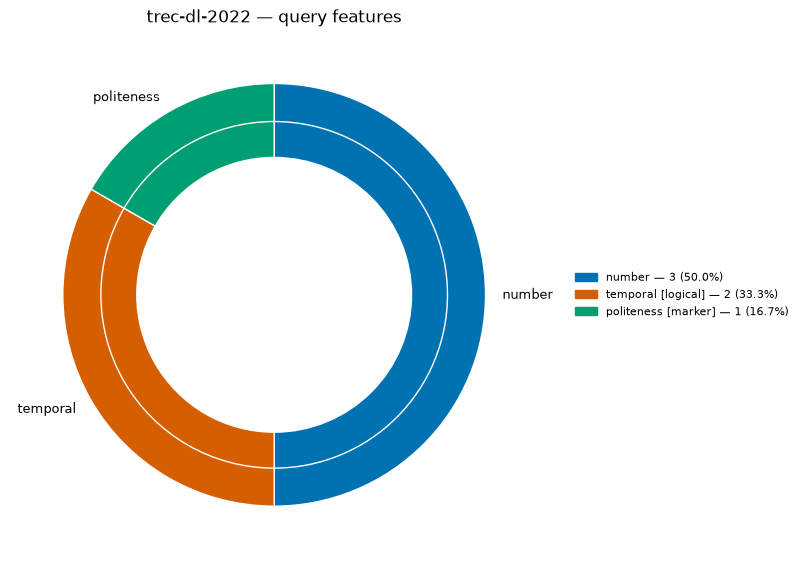

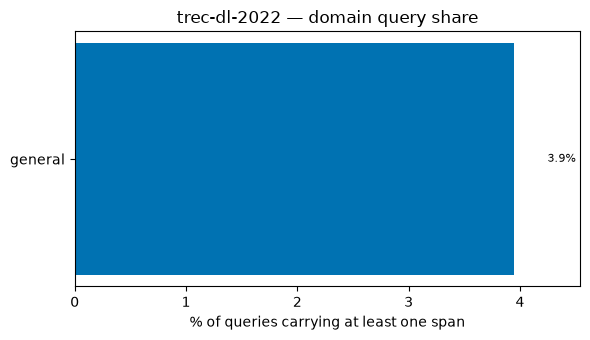


=== nfcorpus ===


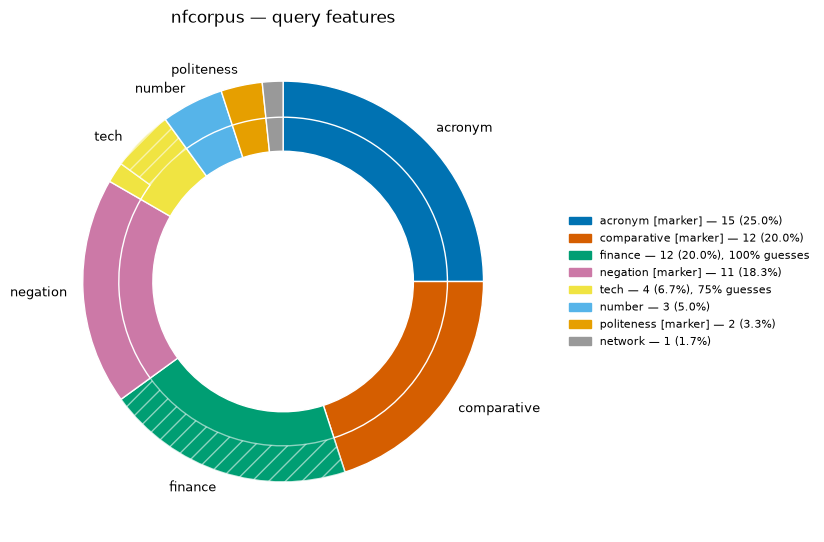

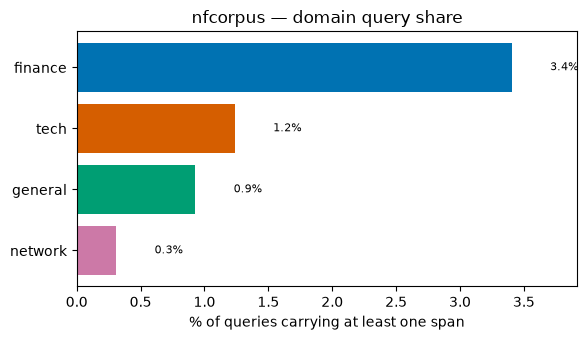


=== scifact ===


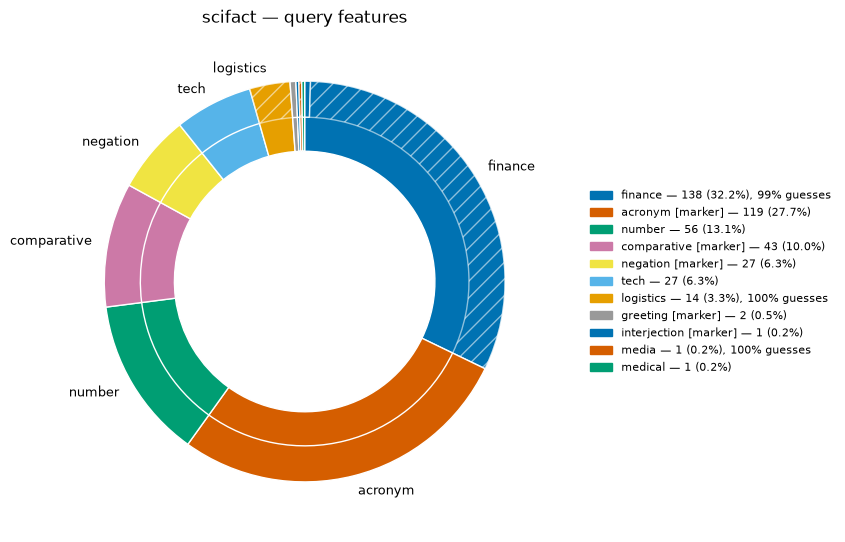

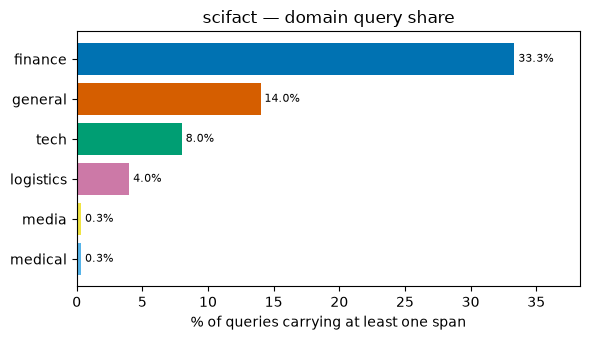

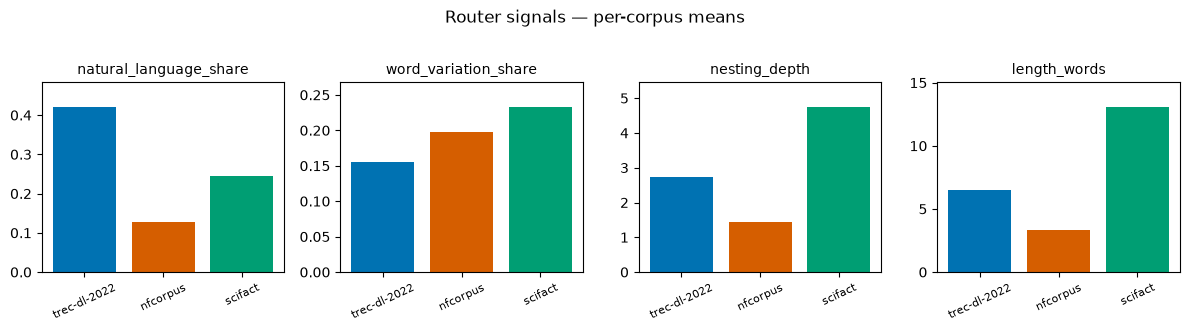

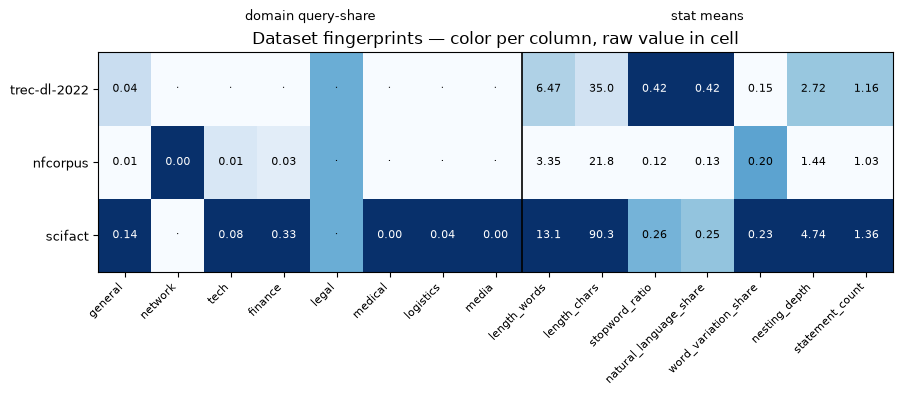

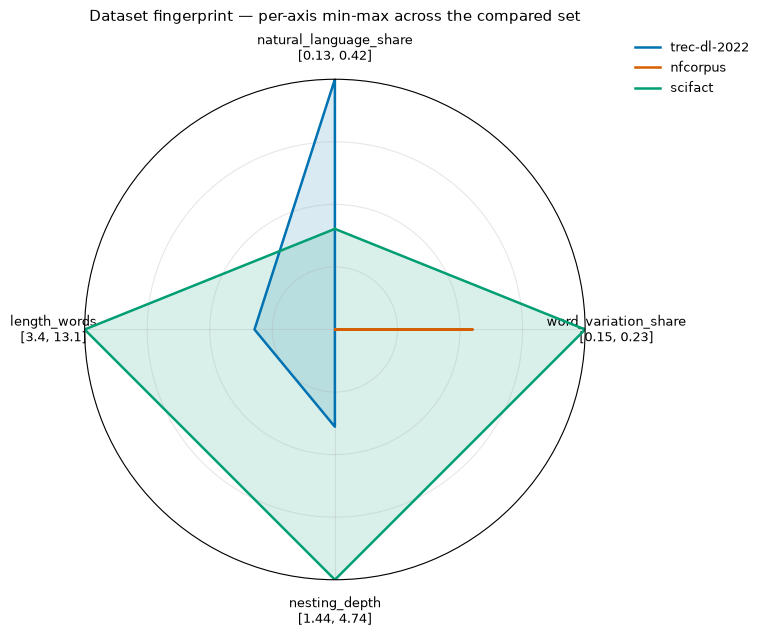

In [6]:
# Same three profiles, now as charts. Two per corpus:
#   * a two-ring domain donut — inner ring by span mass, outer ring split
#     certified vs shape-guesses so the -like doctrine is visible at a glance,
#   * a domain query-share bar — companion "how often does any span from
#     this domain appear at all?", color-matched to the donut.
# Plus one panel comparing the four router signals across the three corpora.

from report_charts import (
    feature_donut, domain_share_bar,
    signal_bars, fingerprint_heatmap, fingerprint_spider,
)
import matplotlib.pyplot as plt

for name, report in reports.items():
    print(f"\n=== {name} ===")
    feature_donut(report, title=f"{name} — query features").tight_layout()
    plt.show()
    domain_share_bar(report, title=f"{name} — domain query share").tight_layout()
    plt.show()

signal_bars(reports)
plt.show()


# Catalog view over every axis — per-column normalization so
# ratios and counts sit on the same chart honestly.
fingerprint_heatmap(reports)
plt.show()

# Comparison view on the four router signals (fixed axis order).
fingerprint_spider(reports)
plt.show()


**What to notice, corpus by corpus — read the four signals as a panel:**

- **trec-dl-2022** — web questions. The *dense-friendly* background: natural-language share 0.42 (proper sentences), ~6.5 words, nesting depth ~2.7, and almost no structured identifiers (3 bare numbers across 76 queries).
- **nfcorpus** — health/nutrition topics. The *telegram* profile: 3.4 words on average, natural-language share 0.13, nesting depth 1.4 — keyword-shaped queries with acronyms (14 queries) and negation markers (11). Sparse-leaning.
- **scifact** — scientific claims. The *hybrid* regime: full sentences (13 words, natural-language share 0.25, nesting depth 4.7) **and** an identifier explosion — 87 of 300 queries carry ticker-shaped tokens (`TCR`, `IL-10`, `miRNA`). NL structure says dense, identifier density says sparse — exactly the queries a router earns its keep on.

## Beat 4 — the self-audit

The profiler doesn't just measure corpora — it audits its own taxonomy. Case in point on SciFact:

In [7]:
import json
from collections import Counter
from pathlib import Path

PROFILES = Path("data/profiles")
scifact = json.loads((PROFILES / "scifact.json").read_text())
identifiers = scifact["span_profiles"]["structured_identifiers"]

suspects = (
    "stock_ticker_like",
    "derivatives_symbol_like",
    "ticket_like",
    "booking_reference_like",
)
print("finance/logistics banks on SciFact — top surface forms:\n")
for name in suspects:
    if name not in identifiers:
        continue
    profile = identifiers[name]
    counts: Counter[str] = Counter()
    for spans in profile["spans"].values():
        for span in spans:
            # FeatureSpan is a NamedTuple -> serializes as [text, start, end]
            counts[span[0]] += 1
    top = counts.most_common(8)
    forms = ", ".join(f"{text} ({n})" for text, n in top)
    print(f"  {name:<24} ({sum(counts.values())} matches) -> {forms}")

finance/logistics banks on SciFact — top surface forms:

  stock_ticker_like        (116 matches) -> DNA (7), TCR (6), PPAR (4), IL (3), IR (3), II (3), UCB (3), UK (2)
  derivatives_symbol_like  (15 matches) -> ALDH1 (2), PIN1 (2), NF2 (2), PGAM1 (1), CHEK2 (1), IF3 (1), IRG1 (1), TIF2 (1)
  ticket_like              (5 matches) -> TDP-43 (2), IL-10 (2), CK-666 (1)
  booking_reference_like   (13 matches) -> CX3CR1 (4), SA1 (2), CD4 (1), EB1 (1), ND3 (1), ND6 (1), CD8 (1), PTENP1 (1)


**The finding:**

None of these are finance instruments. They're **gene/protein symbols and biochemical identifiers** — `TCR`, `IL-10`, `TDP-43`, `ALDH1`, `PIN1`, `CX3CR1`, `miRNA`. Bare caps + digit shapes look identical to tickers/tickets, so the AMBIGUOUS-tier `*_like` banks absorb them.

This is the point:

1. The FP smell test **worked** — off-topic-domain hits are a priori suspect, and the doctrine is encoded in the CorpusReport rollup: `-like` slices carry a `guesses` share in the donut legend, and the `shape-guesses` column in the text report.
2. The FPs pointed at a **real taxonomy gap**: no `GENE_SYMBOL` bank. Scientific corpora have their own identifier family we hadn't modeled.
3. Filling that gap will **simultaneously de-noise finance banks on scientific corpora** — one bank does double duty.

> Profiling doesn't just tell us which corpora to sample — it tells us which banks to build next.

## Takeaways 

- **One extractor, two engines** (regex / spaCy), pluggable via `engines=` — same pipeline handles determinism-first identifiers and parser-backed signals without the caller thinking about it.
- **Four signals, seven scalars** — every stat answers a router question (NL-shape, word variation, structure, size), and the names say what they mean; the how lives in docstrings. Signals are read jointly as a panel.
- **Signals are coordinates and acceptance filters** for the diversified-dataset recipe — strata are boxes in signal space, synthesis is rejection-sampled against them, and **labels always come from retrieval outcomes**, never from the signals themselves.
- **Claim resolution is within-group** — layered banks compete for char ranges by ambiguity tier; groups stay independent layers.
- **The taxonomy is not frozen.** Every profile run is a chance to spot a gap — SciFact just requested a `GENE_SYMBOL` bank.

In [ ]:
from benchmark_engines import benchmark, BenchmarkResult
from query_taxonomy.core import Engine
from pathlib import Path


results: list[BenchmarkResult] = benchmark(
    sizes=[100],     # per-engine timing batch sizes
    engines=[Engine.REGEX, Engine.SPACY],
    warmup=100,                               # per-engine, from pool tail
    query_source="msmarco-passage/train",
    csv_path=Path("./data/engines.csv"),         # None → no CSV write
    verbose=True,                             # False → silent (no tqdm, no print)
)


load 200 queries: 100%|#########9| 199/200 [00:00<00:00, 220344.90it/s]

regex warmup: 100%|##########| 100/100 [00:00<00:00, 13007.61it/s]

regex n=   100: 100%|##########| 100/100 [00:00<00:00, 11831.94it/s]

spacy_model warmup: 100%|##########| 100/100 [00:00<00:00, 1783.71it/s]

spacy_model n=   100: 100%|##########| 100/100 [00:00<00:00, 1849.28it/s]


         regex  n=    100    11,629.5 qps  p50=   0.07 ms  p95=   0.14 ms  p99=   0.30 ms  rss_delta=   +0.0 MB
   spacy_model  n=    100     1,843.6 qps  p50=   0.46 ms  p95=   0.99 ms  p99=   1.24 ms  rss_delta=   +1.5 MB


| Engine | Throughput | Ratio       | 100K queries | 500K queries |
| ------ | ---------: | :---------- | :----------- | :----------- |
| regex  | 10,738 qps | 1×          | 9 s          | 47 s         |
| spacy  |  1,639 qps | 6.5× slower | 61 s         | 5 min        |

Both engines are cheap enough to fingerprint (and rejection-sample) datasets of hundreds of thousands of queries in minutes — the signal panel is free at corpus scale.

In [ ]:
[print(result) for result in results]

BenchmarkResult(run_ts='2026-07-21T11:32:52', engine='regex', n=100, wall_s=0.009, throughput_qps=11629.54, p50_ms=0.074, p95_ms=0.14, p99_ms=0.3, peak_rss_mb=309.9, rss_delta_mb=0.0)
BenchmarkResult(run_ts='2026-07-21T11:32:52', engine='spacy_model', n=100, wall_s=0.054, throughput_qps=1843.62, p50_ms=0.461, p95_ms=0.986, p99_ms=1.236, peak_rss_mb=313.2, rss_delta_mb=1.5)


[None, None]